In [2]:
import scipy
import numpy as np
import embedding_sim, extract_embeddings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_wav2vec2 = pd.read_csv("../Data/wav2vec2_pretrained_embed_data.csv")
df_whisper = pd.read_csv("../Data/Whisper_embed_data.csv")

In [5]:
display(df_wav2vec2)

,Layer,Step,Model,Pair,t-similarity
0,0,0,wav2vec2_pretrained,dash-tash,0.060854
1,0,1,wav2vec2_pretrained,dash-tash,0.157724
2,0,2,wav2vec2_pretrained,dash-tash,0.383994
3,0,3,wav2vec2_pretrained,dash-tash,0.427729
4,0,4,wav2vec2_pretrained,dash-tash,0.569596
...,...,...,...,...,...
281,12,6,wav2vec2_pretrained,task-dask,0.782856
282,12,7,wav2vec2_pretrained,task-dask,0.681136
283,12,8,wav2vec2_pretrained,task-dask,0.914114
284,12,9,wav2vec2_pretrained,task-dask,0.901322


### Test Stuff (can skip) ###

In [21]:
df_averaged = df_whisper.groupby(['Layer', 'Step'])['t-similarity'].mean().reset_index()
#display(df_averaged.tail())
mask = df_averaged['Layer'].isin([3])
print(df_averaged['t-similarity'].values.shape)
print(df_averaged[mask]["t-similarity"].values.shape)
#mask = df_whisper['Layer'].isin([3])
#print(df_whisper[mask]["t-similarity"].values)
display(df_averaged)

(143,)
(11,)


,Layer,Step,t-similarity
0,0,0,0.007273
1,0,1,0.029986
2,0,2,0.067560
3,0,3,0.084389
4,0,4,0.403104
...,...,...,...
138,12,6,0.831447
139,12,7,0.838037
140,12,8,0.929412
141,12,9,0.920987


### Real Stuff ###

In [6]:
def sigmoid(x, L, x0, k):
    return L / (1 + np.exp(-k * (x - x0)))

def fit_single_layer(layer_df):
    x_data = np.arange(1, 12)
    y_data = layer_df["t-similarity"].values

    # Fit the data points to a sigmoid curve
    popt, pcov = scipy.optimize.curve_fit(sigmoid, x_data, y_data, p0=[1.0, 6.0, 1.0])
    L, x0, k = popt
    y_fitted = sigmoid(x_data, L, x0, k)

    # Calculate Mean Absolute Error (MAE)
    mae = np.mean(np.abs(y_data - y_fitted))
    
    return popt, mae

def run_all_layers(embed_data):
    # Average over pairs
    embed_data = embed_data.groupby(['Layer', 'Step'])['t-similarity'].mean().reset_index()
    
    results_list = []
    
    for layer in range(13):
        mask = embed_data['Layer'].isin([layer])
        popt, mae = fit_single_layer(embed_data[mask])
        
        results_list.append({
            'Layer': layer,
            'k': popt[2],
            'mae': mae
        })
        
    return pd.DataFrame(results_list)

### Plots ###
to do: combine the funcs

In [9]:
def plot_param_change(whisper_df, wav2vec2_df, parameter, y_axis_name):
    """ Layer-wise param change: options include 'k' and 'mae' """
    
    layers = ["CNN"] + [f"T{i}" for i in range(1, 13)]
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    whisper_param_mean = whisper_df[parameter].mean()
    wav2vec2_param_mean = wav2vec2_df[parameter].mean()

    # Whisper parameter change
    sns.lineplot(data=whisper_df, x=layers, y=parameter, 
                 color='#800080', marker='o', label='Whisper')

    # Whisper parameter mean
    plt.axhline(
        whisper_param_mean,
        linestyle="--",
        alpha=0.5,
        color='#800080',
        label="Whisper mean"
    )

    # wav2vec2 parameter change
    sns.lineplot(data=wav2vec2_df, x=layers, y=parameter, 
                 color='#808080', marker='s', label='wav2vec2')

    # wav2vec2 parameter mean
    plt.axhline(
        wav2vec2_param_mean,
        linestyle="--",
        alpha=0.5,
        color='#808080',
        label="wav2vec2 mean"
    )

    plt.xlabel("Layer", fontsize=12)
    plt.ylabel(y_axis_name, fontsize=12)
    plt.xticks(np.arange(0, 13, 1)) 
    
    sns.despine()
    plt.legend(frameon=True)
    plt.savefig(f"layerwise_{parameter}.png", dpi=300, bbox_inches='tight')
    plt.show()
    

In [11]:
results_whisper = run_all_layers(df_whisper)
results_wav2vec2 = run_all_layers(df_wav2vec2)

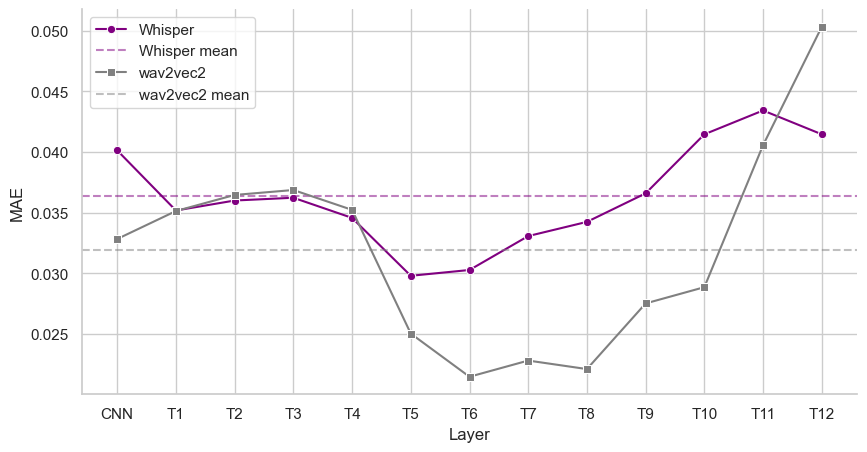

In [13]:
plot_param_change(results_whisper, results_wav2vec2, 'mae', 'MAE')

In [13]:
def plot_k_change(whisper_df, wav2vec2_df, parameter):
    layers = ["CNN"] + [f"T{i}" for i in range(1, 13)]
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    whisper_k_mean = whisper_df['k'].mean()
    wav2vec2_k_mean = wav2vec2_df['k'].mean()

    # Whisper k evolution
    sns.lineplot(data=whisper_df, x=layers, y='k', 
                 color='#800080', marker='o', label='Whisper')

    # Whisper k mean
    plt.axhline(
        whisper_k_mean,
        linestyle="--",
        alpha=0.5,
        color='#800080',
        label="Whisper mean"
    )

    # wav2vec2 k evolution
    sns.lineplot(data=wav2vec2_df, x=layers, y='k', 
                 color='#808080', marker='s', label='wav2vec2')

    # wav2vec2 k mean
    plt.axhline(
        wav2vec2_k_mean,
        linestyle="--",
        alpha=0.5,
        color='#808080',
        label="wav2vec2 mean"
    )

    #plt.title("Category-like transition steepness across layers", fontsize=14)
    plt.xlabel("Layer", fontsize=12)
    plt.ylabel("Sigmoid Slope (k)", fontsize=12)
    plt.xticks(np.arange(0, 13, 1)) 
    
    sns.despine()
    plt.legend(frameon=True)
    plt.savefig("layerwise_k.png", dpi=300, bbox_inches='tight')
    plt.show()

In [16]:
def plot_mae_change(whisper_df, wav2vec2_df):
    layers = ["CNN"] + [f"T{i}" for i in range(1, 13)]
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    whisper_mae_mean = whisper_df['mae'].mean()
    wav2vec2_mae_mean = wav2vec2_df['mae'].mean()

    # Whisper mae evolution
    sns.lineplot(data=whisper_df, x=layers, y='mae', 
                 color='#800080', marker='o', label='Whisper')

    # Whisper global mae
    plt.axhline(
        whisper_mae_mean,
        linestyle="--",
        alpha=0.5,
        color='#800080',
        label="Whisper mean"
    )

    # wav2vec2 mae evolution
    sns.lineplot(data=wav2vec2_df, x=layers, y='mae', 
                 color='#808080', marker='s', label='wav2vec2')

    # wav2vec2 global mae
    plt.axhline(
        wav2vec2_mae_mean,
        linestyle="--",
        alpha=0.5,
        color='#808080',
        label="wav2vec2 mean"
    )

    #plt.title("MAE of Sigmoid Fits across Layers", fontsize=14)
    plt.xlabel("Layer", fontsize=12)
    plt.ylabel("Mean Absolute Error (MAE)", fontsize=12)
    plt.xticks(np.arange(0, 13, 1)) 
    
    sns.despine()
    plt.legend(frameon=True)
    plt.savefig("layerwise_mae.png", dpi=300, bbox_inches='tight')
    plt.show()

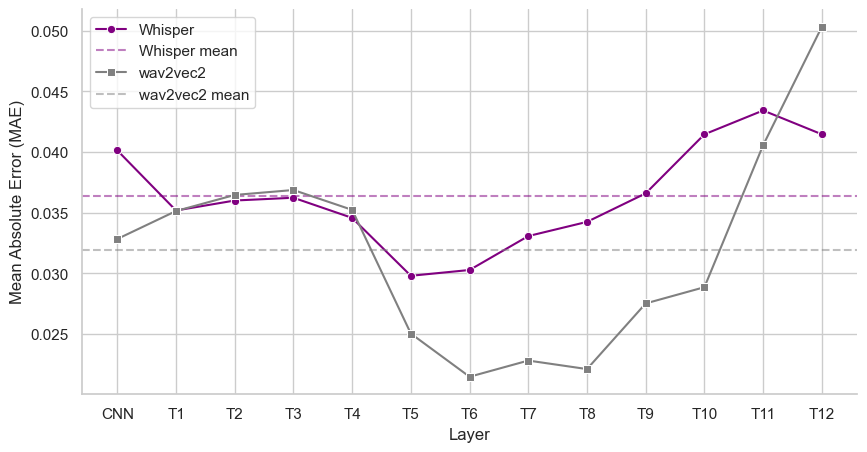

In [17]:
#plot_k_change(results_whisper, results_wav2vec2)
plot_mae_change(results_whisper, results_wav2vec2)

## Stats ##
### Comparison of k between groups - excl the outlier ### 

In [89]:
from scipy import stats

diff = results_whisper['k'].iloc[0:11] - results_wav2vec2['k'].iloc[0:11]

result = stats.ttest_rel(results_whisper['k'].iloc[0:11], results_wav2vec2['k'].iloc[0:11])
ci = result.confidence_interval(confidence_level=0.95)

print("Mean Whisper k:", results_whisper['k'].iloc[0:11].mean())
print("Mean Wav2Vec2 k:", results_wav2vec2['k'].iloc[0:11].mean())
print("Mean diff:", diff.mean())
print("95% CI:", ci)
print("t:", result.statistic)
print("p-val:", result.pvalue)

Mean Whisper k: 0.6928780201062499
Mean Wav2Vec2 k: 0.5274610098375287
Mean diff: 0.16541701026872116
95% CI: ConfidenceInterval(low=np.float64(0.09465910233611423), high=np.float64(0.23617491820132808))
t: 5.208916969487929
p-val: 0.0003961603119367764


### Comparison of k between groups - incl the outlier ### 

In [90]:
from scipy import stats

diff = results_whisper['k'] - results_wav2vec2['k']

result = stats.ttest_rel(results_whisper['k'], results_wav2vec2['k'])
ci = result.confidence_interval(confidence_level=0.95)

print("Mean Whisper k:", results_whisper['k'].mean())
print("Mean Wav2Vec2 k:", results_wav2vec2['k'].mean())
print("Mean diff:", diff.mean())
print("95% CI:", ci)
print("t:", result.statistic)
print("p-val:", result.pvalue)

Mean Whisper k: 0.7185062569908834
Mean Wav2Vec2 k: 0.5864764937143708
Mean diff: 0.13202976327651256
95% CI: ConfidenceInterval(low=np.float64(0.05245190004208443), high=np.float64(0.21160762651094067))
t: 3.6149266948378473
p-val: 0.003547418960207447


In [91]:
print(results_wav2vec2['mae'].mean())

0.03194903142028201


In [92]:
results_whisper.describe()

,Layer,k,mae
count,13.00000,13.000000,13.000000
mean,6.00000,0.718506,0.036348
std,3.89444,0.097443,0.004244
min,0.00000,0.598555,0.029809
25%,3.00000,0.618787,0.034249
50%,6.00000,0.708437,0.036009
75%,9.00000,0.788998,0.040138
max,12.00000,0.892393,0.043429


In [93]:
results_wav2vec2.describe()

,Layer,k,mae
count,13.00000,13.000000,13.000000
mean,6.00000,0.586476,0.031949
std,3.89444,0.156427,0.008389
min,0.00000,0.477663,0.021489
25%,3.00000,0.509164,0.025045
50%,6.00000,0.529230,0.032841
75%,9.00000,0.572659,0.036468
max,12.00000,1.037440,0.050327


### QUANTIFYING MAIN GANONG EFFECT ###

In [3]:
df_wav2vec2_ft = pd.read_csv("../Data/wav2vec2_finetuned_embed_data.csv")

In [4]:
display(df_wav2vec2_ft.tail())

,Layer,Step,Model,Pair,t-similarity
281,12,6,wav2vec2_finetuned,task-dask,0.907327
282,12,7,wav2vec2_finetuned,task-dask,0.919816
283,12,8,wav2vec2_finetuned,task-dask,0.945201
284,12,9,wav2vec2_finetuned,task-dask,0.937729
285,12,10,wav2vec2_finetuned,task-dask,0.949700


In [7]:
def sigmoid(x, L, x0, k):
    return L / (1 + np.exp(-k * (x - x0)))

def fit_single_layer(layer_df):
    x_data = np.arange(1, 12)
    y_data = layer_df["t-similarity"].values

    # The fit
    popt, pcov = scipy.optimize.curve_fit(sigmoid, x_data, y_data, p0=[1.0, 6.0, 1.0])
    L, x0, k = popt
    y_fitted = sigmoid(x_data, L, x0, k)

    # Mean Absolute Error
    mae = np.mean(np.abs(y_data - y_fitted))
    
    return popt, mae

In [13]:
display(df_wav2vec2_ft[mask_dash])

,Layer,Step,Model,Pair,t-similarity
264,12,0,wav2vec2_finetuned,dash-tash,0.173088
265,12,1,wav2vec2_finetuned,dash-tash,0.213148
266,12,2,wav2vec2_finetuned,dash-tash,0.314407
267,12,3,wav2vec2_finetuned,dash-tash,0.339126
268,12,4,wav2vec2_finetuned,dash-tash,0.323150
269,12,5,wav2vec2_finetuned,dash-tash,0.767626
270,12,6,wav2vec2_finetuned,dash-tash,0.876570
271,12,7,wav2vec2_finetuned,dash-tash,0.845437
272,12,8,wav2vec2_finetuned,dash-tash,0.915387
273,12,9,wav2vec2_finetuned,dash-tash,0.919553


In [16]:
mask_dash = df_wav2vec2_ft['Layer'].isin([12]) & df_wav2vec2_ft['Pair'].isin(['dash-tash'])
mask_task = df_wav2vec2_ft['Layer'].isin([12]) & df_wav2vec2_ft['Pair'].isin(['task-dask'])

popt, mae = fit_single_layer(df_wav2vec2_ft[mask_dash])
popt2, mae2 = fit_single_layer(df_wav2vec2_ft[mask_task])

ganong_shift = popt[1] - popt2[1]

print(ganong_shift)

0.7378696359491075


In [17]:
mask_dash = df_wav2vec2_ft['Layer'].isin([11]) & df_wav2vec2_ft['Pair'].isin(['dash-tash'])
mask_task = df_wav2vec2_ft['Layer'].isin([11]) & df_wav2vec2_ft['Pair'].isin(['task-dask'])

popt, mae = fit_single_layer(df_wav2vec2_ft[mask_dash])
popt2, mae2 = fit_single_layer(df_wav2vec2_ft[mask_task])

ganong_shift = popt[1] - popt2[1]

print(ganong_shift)

-1.9502275398707147
